# WR Best Final Models — Consolidated Notebook

Finalni notebook koji konsoliduje **najbolje verzije svih modela** iz WR pipeline-a.
Svi hiperparametri su fiksirani iz ranijih eksperimenata (Optuna, ablacije).

## Modeli u notebook-u

**Baseline ML (3 modela):**
1. RandomForest
2. XGBoost
3. LightGBM

**MLP (2 modela):**
4. MLP Hybrid (Huber loss + GaussianNoise)
5. MLP Quantile q50 (pinball loss) — najbolji single-model MAE

**Sekvencni (2 modela):**
6. LSTM (Optuna-tuned, dual-branch, seq_len=12) — najbolji single RNN
7. GRU (Optuna-tuned, dual-branch, seq_len=12)

**Ensemble:**
8. Constrained LS ensemble — weighted kombinacija top modela (bez ElasticNet-a)

## Uniformni protokol

- **Temporal split:** train 2015-2021, val 2022-2023, test 2024-2025
- **Target (tabular):** `sqrt(receiving_yards)`
- **Target (sekvencni):** `sqrt(receiving_yards)` (LSTM/GRU) - best Optuna izbor
- **Sample weights:** `1 + strength * sqrt(y / mean_y)` (strength=0.6 tabular / 0.6 sekvencni)
- **Seed:** 42
- **Features (tabular):** top-40 iz `selected_features_top40.json`
- **Features (sekvencni):** 33 raw per-game stats + 20 static pregame features


---
## 1. Imports


In [3]:
import warnings
warnings.filterwarnings('ignore')

import os, json, time, random
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, losses, Model, Input
from tensorflow.keras.layers import (
    Dense, Dropout, LayerNormalization, GaussianNoise,
    LSTM, GRU, Masking, Concatenate,
)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = (14, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

PROJECT_ROOT = Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / 'data' / 'fully combined' / 'wr_all_weeks.csv'
RESULTS_DIR = PROJECT_ROOT / 'results'
if not DATA_PATH.exists():
    for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        candidate_data_path = candidate / 'data' / 'fully combined' / 'wr_all_weeks.csv'
        if candidate_data_path.exists():
            PROJECT_ROOT = candidate
            DATA_PATH = candidate_data_path
            RESULTS_DIR = PROJECT_ROOT / 'results'
            break
    else:
        raise FileNotFoundError(f'Could not find wr_all_weeks.csv from {Path.cwd()}')

print(f'TensorFlow {tf.__version__}')
print(f'Project root: {PROJECT_ROOT}')
print(f'Data path: {DATA_PATH}')

TensorFlow 2.21.0
Project root: C:\Users\Korisnik\Documents\GitHub\Analiza-i-Obrada
Data path: C:\Users\Korisnik\Documents\GitHub\Analiza-i-Obrada\data\fully combined\wr_all_weeks.csv


---
## 2. Feature Engineering (tabular + sequence)

Ista priprema kao u `WR_Ensemble_Final` + dodatni raw cols za sekvencne modele.


In [4]:
df = pd.read_csv(DATA_PATH)
df['week'] = df['game_id'].str.split('_').str[1].astype(int)
df = df.sort_values(['receiver_player_id', 'season', 'week']).reset_index(drop=True)

work_df = df.copy()

# Rename win-prob columns for safe identifiers
wp_rename_map = {
    'yards_wp_<25':       'yards_wp_less_than_25',
    'yards_wp_>75':       'yards_wp_greater_than_75',
    'receptions_wp_<25':  'receptions_wp_less_than_25',
    'receptions_wp_>75':  'receptions_wp_greater_than_75',
    'targets_wp_<25':     'targets_wp_less_than_25',
    'targets_wp_>75':     'targets_wp_greater_than_75',
}
work_df = work_df.rename(columns={k: v for k, v in wp_rename_map.items() if k in work_df.columns})

# Team detection
work_df['player_team_inferred'] = np.where(
    (work_df['home_team'] == work_df['defteam']) & (work_df['away_team'] != work_df['defteam']),
    work_df['away_team'],
    np.where(
        (work_df['away_team'] == work_df['defteam']) & (work_df['home_team'] != work_df['defteam']),
        work_df['home_team'], np.nan,
    ),
)
prev_team = work_df.groupby('receiver_player_id')['player_team_inferred'].shift(1)
work_df['team_changed'] = (
    work_df['player_team_inferred'].notna()
    & prev_team.notna()
    & (work_df['player_team_inferred'] != prev_team)
).astype(int)

prev_season = work_df.groupby('receiver_player_id')['season'].shift(1)
work_df['is_new_season'] = (prev_season.notna() & (work_df['season'] != prev_season)).astype(int)

work_df['season_week_abs'] = (work_df['season'] - 2015) * 22 + work_df['week']
work_df['weeks_since_last_game'] = (
    work_df.groupby('receiver_player_id')['season_week_abs']
    .diff().fillna(1).clip(lower=1).astype(float)
)
work_df.drop(columns=['season_week_abs'], inplace=True)

# Career averages from last season
season_career = (
    work_df.groupby(['receiver_player_id', 'season'], as_index=False)
    .agg(avg_yards=('receiving_yards', 'mean'),
         avg_target_share=('target_share', 'mean'),
         avg_epa=('epa', 'mean'),
         avg_air_yard_share=('air_yard_share', 'mean'),
         avg_catch_rate=('catch_rate', 'mean'),
         games_played=('game_id', 'count'))
    .sort_values(['receiver_player_id', 'season'])
)
for c in ['avg_yards', 'avg_target_share', 'avg_epa',
          'avg_air_yard_share', 'avg_catch_rate', 'games_played']:
    season_career[f'{c}_last_season'] = (
        season_career.groupby('receiver_player_id')[c].shift(1)
    )
career_cols = [f'{c}_last_season' for c in
               ['avg_yards', 'avg_target_share', 'avg_epa',
                'avg_air_yard_share', 'avg_catch_rate', 'games_played']]
season_career = season_career[['receiver_player_id', 'season'] + career_cols]
work_df = work_df.merge(season_career, on=['receiver_player_id', 'season'], how='left')
work_df[career_cols] = work_df[career_cols].fillna(0)

print(f'Base dataset: {work_df.shape}')

Base dataset: (46115, 110)


In [5]:
# Rolling / lag / momentum / interaction features (produce top-40 space)
rolling_source_cols = [
    'targets', 'receptions', 'air_yards', 'yac', 'tds', 'epa', 'wpa', 'catch_rate',
    'avg_depth', 'adot', 'yac_per_reception', 'td_rate', 'explosive_plays', 'first_downs',
    'yards_per_target', 'team_pass_attempts', 'team_air_yards', 'team_epa', 'air_yard_share',
    'target_share', 'qb_completions', 'qb_attempts', 'qb_air_yards', 'qb_cpoe', 'qb_comp_pct',
    'avg_score_diff', 'trailing_pct', 'leading_pct', 'avg_quarter', 'success_rate',
    'big_play_rate', 'avg_start_yardline', 'red_zone_targets', 'end_zone_targets',
    'third_down_targets', 'fourth_down_targets', 'high_leverage_targets',
    'second_and_long_targets', 'third_and_medium_targets', 'wp_var', 'target_share_std',
    'reception_std', 'def_targets_dev', 'def_receptions_dev', 'def_yards_dev', 'def_tds_dev',
    'def_epa_dev', 'yards_Q1', 'yards_Q2', 'yards_Q3', 'yards_Q4',
    'receptions_Q1', 'receptions_Q2', 'receptions_Q3', 'receptions_Q4',
    'targets_Q1', 'targets_Q2', 'targets_Q3', 'targets_Q4',
    'lost_yards_due_to_penalty',
    'yards_wp_less_than_25', 'yards_wp_25_45', 'yards_wp_45_55',
    'yards_wp_55_75', 'yards_wp_greater_than_75',
    'receptions_wp_less_than_25', 'receptions_wp_25_45', 'receptions_wp_45_55',
    'receptions_wp_55_75', 'receptions_wp_greater_than_75',
    'targets_wp_less_than_25', 'targets_wp_25_45', 'targets_wp_45_55',
    'targets_wp_55_75', 'targets_wp_greater_than_75',
    'weeks_since_last_game',
]
available_roll_cols = [c for c in rolling_source_cols if c in work_df.columns]
grp = work_df.groupby('receiver_player_id', sort=False)
derived_cols = []
for col in available_roll_cols:
    work_df[f'{col}_lag1']  = grp[col].transform(lambda s: s.shift(1))
    work_df[f'{col}_roll5'] = grp[col].transform(
        lambda s: s.shift(1).rolling(window=5, min_periods=1).mean()
    )
    derived_cols.extend([f'{col}_lag1', f'{col}_roll5'])

# Momentum features (lag1 - roll5)
momentum_sources = [
    'targets', 'receptions', 'air_yards', 'epa', 'catch_rate',
    'target_share', 'yards_per_target', 'air_yard_share',
]
momentum_cols = []
for col in momentum_sources:
    lag1_col, roll5_col = f'{col}_lag1', f'{col}_roll5'
    if lag1_col in work_df.columns and roll5_col in work_df.columns:
        mcol = f'{col}_momentum'
        work_df[mcol] = work_df[lag1_col] - work_df[roll5_col]
        momentum_cols.append(mcol)

# Interaction features
interaction_cols = []
if 'target_share_lag1' in work_df.columns:
    work_df['target_volume_interaction'] = (
        work_df['target_share_lag1'] * work_df['pregame_total']
    )
    interaction_cols.append('target_volume_interaction')
if 'air_yard_share_lag1' in work_df.columns and 'team_pass_attempts_lag1' in work_df.columns:
    work_df['air_yards_expected'] = (
        work_df['air_yard_share_lag1'] * work_df['team_pass_attempts_lag1']
    )
    interaction_cols.append('air_yards_expected')
if 'catch_rate_lag1' in work_df.columns and 'targets_lag1' in work_df.columns:
    work_df['expected_receptions'] = (
        work_df['catch_rate_lag1'] * work_df['targets_lag1']
    )
    interaction_cols.append('expected_receptions')
if 'epa_lag1' in work_df.columns and 'targets_lag1' in work_df.columns:
    work_df['epa_per_target'] = (
        work_df['epa_lag1'] / work_df['targets_lag1'].replace(0, np.nan)
    ).fillna(0)
    interaction_cols.append('epa_per_target')

pregame_features = [
    'pregame_spread', 'pregame_total', 'surface', 'is_dome', 'temp_f',
    'humidity_pct', 'wind_mph', 'is_rain', 'is_snow', 'is_clear',
    'season', 'week', 'team_changed', 'is_new_season',
]
all_feature_columns = (
    pregame_features + career_cols + derived_cols + momentum_cols + interaction_cols
)

model_df = work_df.copy()
lag1_all = [c for c in all_feature_columns if c.endswith('_lag1')]
model_df = model_df.loc[~model_df[lag1_all].isna().all(axis=1)].copy()
model_df = model_df.loc[:, ~model_df.columns.duplicated()]
model_df[all_feature_columns] = model_df[all_feature_columns].fillna(0)
model_df['receiving_yards_sqrt'] = np.sqrt(model_df['receiving_yards'].clip(lower=0))

print(f'Modeling dataset: {model_df.shape}')
print(f'Tabular features engineered: {len(all_feature_columns)}')


Modeling dataset: (44396, 275)
Tabular features engineered: 184


---
## 3. Tabular Split + Top-40 + Sample Weights


In [6]:
train_seasons = list(range(2015, 2022))
val_seasons = [2022, 2023]
test_seasons = [2024, 2025]

train_df = model_df[model_df['season'].isin(train_seasons)].copy()
val_df   = model_df[model_df['season'].isin(val_seasons)].copy()
test_df  = model_df[model_df['season'].isin(test_seasons)].copy()

y_train_sqrt = train_df['receiving_yards_sqrt'].values
y_val_sqrt   = val_df['receiving_yards_sqrt'].values
y_test_sqrt  = test_df['receiving_yards_sqrt'].values
y_train_orig = train_df['receiving_yards'].values
y_val_orig   = val_df['receiving_yards'].values
y_test_orig  = test_df['receiving_yards'].values

with open(PROJECT_ROOT / 'results' / 'selected_features_top40.json', 'r') as f:
    selected_features = json.load(f)['selected_features']

missing = [f for f in selected_features if f not in train_df.columns]
if missing:
    raise ValueError(f'Missing top-40 features: {missing}')

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[selected_features].values)
X_val   = scaler.transform(val_df[selected_features].values)
X_test  = scaler.transform(test_df[selected_features].values)

mean_y_train = np.mean(np.clip(y_train_orig, 0, None))
sw_train = 1.0 + 0.6 * np.sqrt(np.clip(y_train_orig, 0, None) / mean_y_train)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'Features: {X_train.shape[1]} (top-40)')
print(f'Sample weights range: [{sw_train.min():.2f}, {sw_train.max():.2f}]')

Train: (29276, 40)  Val: (8921, 40)  Test: (6199, 40)
Features: 40 (top-40)
Sample weights range: [1.00, 2.87]


---
## 4. Utility Functions


In [7]:
def eval_preds(y_true_orig, y_pred_orig):
    return {
        'MAE':  float(mean_absolute_error(y_true_orig, y_pred_orig)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))),
        'R2':   float(r2_score(y_true_orig, y_pred_orig)),
    }

def sqrt_to_orig(p):
    return np.clip(p, 0, None) ** 2

# holds per-model {val, test, seconds, val_pred_orig, test_pred_orig}
results = {}

def log_result(name, val_metrics, test_metrics, seconds=None,
               val_pred=None, test_pred=None):
    results[name] = {
        'val': val_metrics, 'test': test_metrics, 'seconds': seconds,
        'val_pred': val_pred, 'test_pred': test_pred,
    }
    s = f' ({seconds:.0f}s)' if seconds is not None else ''
    print(f'{name:32}{s}  val MAE={val_metrics["MAE"]:.3f}  '
          f'test MAE={test_metrics["MAE"]:.3f}  R2={test_metrics["R2"]:.4f}')

print('Utils defined.')


Utils defined.


---
## 5. Baseline ML Models (3 modela)

Tri klasicna ML modela kao baseline — treniranja su brza, interpretabilna i daju
referentne vrednosti koje kasnije duboki modeli trebaju da nadmasuju.


### 5.1 RandomForest

**Arhitektura:** 300 stabala, `max_depth=10`, `min_samples_leaf=4`, sqrt target,
sample weights 0.6.


In [8]:
t0 = time.time()
rf = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=4,
    random_state=SEED, n_jobs=-1,
)
rf.fit(X_train, y_train_sqrt, sample_weight=sw_train)

rf_val_pred  = sqrt_to_orig(rf.predict(X_val))
rf_test_pred = sqrt_to_orig(rf.predict(X_test))
log_result('RandomForest',
           eval_preds(y_val_orig,  rf_val_pred),
           eval_preds(y_test_orig, rf_test_pred),
           time.time() - t0,
           val_pred=rf_val_pred, test_pred=rf_test_pred)


RandomForest                     (10s)  val MAE=18.129  test MAE=17.853  R2=0.3321


### 5.2 XGBoost

**Arhitektura:** 800 stabala, `max_depth=6`, `learning_rate=0.03`, `subsample=0.85`,
`colsample_bytree=0.85`, `min_child_weight=4`, `gamma=0.1`, L1=0.1, L2=1.0.


In [9]:
t0 = time.time()
xgb = XGBRegressor(
    n_estimators=800, max_depth=6, learning_rate=0.03,
    subsample=0.85, colsample_bytree=0.85,
    min_child_weight=4, gamma=0.1,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=SEED, tree_method='hist', verbosity=0,
)
xgb.fit(X_train, y_train_sqrt, sample_weight=sw_train,
        eval_set=[(X_val, y_val_sqrt)], verbose=False)

xgb_val_pred  = sqrt_to_orig(xgb.predict(X_val))
xgb_test_pred = sqrt_to_orig(xgb.predict(X_test))
log_result('XGBoost',
           eval_preds(y_val_orig,  xgb_val_pred),
           eval_preds(y_test_orig, xgb_test_pred),
           time.time() - t0,
           val_pred=xgb_val_pred, test_pred=xgb_test_pred)


XGBoost                          (2s)  val MAE=18.187  test MAE=18.016  R2=0.3152


### 5.3 LightGBM

**Arhitektura:** 1000 stabala, `num_leaves=63`, `learning_rate=0.03`, `feature_fraction=0.85`,
`bagging_fraction=0.85`, `bagging_freq=5`, `min_child_samples=20`, L1=0.1, L2=0.1.


In [10]:
t0 = time.time()
lgb = LGBMRegressor(
    n_estimators=1000, num_leaves=63, learning_rate=0.03,
    feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=5,
    min_child_samples=20, reg_alpha=0.1, reg_lambda=0.1,
    random_state=SEED, verbosity=-1,
)
lgb.fit(X_train, y_train_sqrt, sample_weight=sw_train,
        eval_set=[(X_val, y_val_sqrt)])

lgb_val_pred  = sqrt_to_orig(lgb.predict(X_val))
lgb_test_pred = sqrt_to_orig(lgb.predict(X_test))
log_result('LightGBM',
           eval_preds(y_val_orig,  lgb_val_pred),
           eval_preds(y_test_orig, lgb_test_pred),
           time.time() - t0,
           val_pred=lgb_val_pred, test_pred=lgb_test_pred)


LightGBM                         (4s)  val MAE=18.203  test MAE=18.110  R2=0.3061


---
## 6. MLP Models (2 modela)

Oba MLP-ja koriste **istu arhitekturu** — najbolja konfiguracija iz `WR_MLP_Hybrid`
(Optuna Model-B) + GaussianNoise(0.15).

### Zajednicka MLP arhitektura

- **Ulazni sloj:** 40 top-features (StandardScaler-ovane)
- **GaussianNoise(0.15)** na ulazu (regularizacija)
- **5 Dense slojeva:** `[448, 128, 320, 448, 256]` sa ReLU aktivacijom
- **LayerNormalization** posle svakog Dense sloja
- **Dropout(0.5)**, na poslednjem sloju polovicni (0.25)
- **Izlazni sloj:** 1 neuron (linearni output, predvidja `sqrt(yards)`)
- **Optimizator:** AdamW (`lr=3.7e-3`, `weight_decay=1.5e-5`)
- **Batch size:** 32, EarlyStopping (patience=30), ReduceLROnPlateau

Razlika izmedju dva modela je samo **loss funkcija:**
- **MLP Hybrid:** Huber loss (δ=0.5) — robusan na outliere
- **MLP Quantile q50:** Pinball loss (τ=0.5) — direktno optimizuje medijanu,
  daje najnizi MAE u projektu


In [11]:
MLP_PARAMS = {
    'n_layers': 5,
    'units': [448, 128, 320, 448, 256],
    'dropout': 0.5,
    'huber_delta': 0.5,
    'lr': 0.003701177981657943,
    'weight_decay': 1.5007044511603625e-05,
    'batch_size': 32,
}

def build_mlp(input_dim, params, loss_fn, noise_stddev=0.15):
    model = keras.Sequential()
    model.add(Input(shape=(input_dim,)))
    model.add(GaussianNoise(noise_stddev))
    for i in range(params['n_layers']):
        model.add(Dense(params['units'][i], activation='relu'))
        model.add(LayerNormalization())
        dr = params['dropout'] * (0.5 if i >= params['n_layers'] - 1 else 1.0)
        model.add(Dropout(dr))
    model.add(Dense(1))
    opt = optimizers.AdamW(learning_rate=params['lr'],
                           weight_decay=params['weight_decay'])
    model.compile(optimizer=opt, loss=loss_fn, metrics=['mae'])
    return model


def pinball_loss_q50(y_true, y_pred):
    e = y_true - y_pred
    return tf.reduce_mean(tf.maximum(0.5 * e, (0.5 - 1.0) * e))


print('MLP builder ready.')


MLP builder ready.


### 6.1 MLP Hybrid (Huber loss)


In [12]:
t0 = time.time()
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

mlp_h = build_mlp(X_train.shape[1], MLP_PARAMS,
                  losses.Huber(delta=MLP_PARAMS['huber_delta']))

cb_h = [
    callbacks.EarlyStopping(monitor='val_loss', patience=30,
                            restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                patience=10, min_lr=1e-6),
]

hist_h = mlp_h.fit(
    X_train, y_train_sqrt, sample_weight=sw_train,
    validation_data=(X_val, y_val_sqrt),
    epochs=500, batch_size=MLP_PARAMS['batch_size'],
    callbacks=cb_h, verbose=0,
)

mlp_h_val_pred  = sqrt_to_orig(mlp_h.predict(X_val,  verbose=0).flatten())
mlp_h_test_pred = sqrt_to_orig(mlp_h.predict(X_test, verbose=0).flatten())
log_result('MLP Hybrid (Huber)',
           eval_preds(y_val_orig,  mlp_h_val_pred),
           eval_preds(y_test_orig, mlp_h_test_pred),
           time.time() - t0,
           val_pred=mlp_h_val_pred, test_pred=mlp_h_test_pred)



MLP Hybrid (Huber)               (207s)  val MAE=18.269  test MAE=18.046  R2=0.3219


### 6.2 MLP Quantile q50 (pinball loss)


In [13]:
t0 = time.time()
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

mlp_q = build_mlp(X_train.shape[1], MLP_PARAMS, pinball_loss_q50)

cb_q = [
    callbacks.EarlyStopping(monitor='val_loss', patience=30,
                            restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                patience=10, min_lr=1e-6),
]

hist_q = mlp_q.fit(
    X_train, y_train_sqrt, sample_weight=sw_train,
    validation_data=(X_val, y_val_sqrt),
    epochs=500, batch_size=MLP_PARAMS['batch_size'],
    callbacks=cb_q, verbose=0,
)

mlp_q_val_pred  = sqrt_to_orig(mlp_q.predict(X_val,  verbose=0).flatten())
mlp_q_test_pred = sqrt_to_orig(mlp_q.predict(X_test, verbose=0).flatten())
log_result('MLP Quantile q50',
           eval_preds(y_val_orig,  mlp_q_val_pred),
           eval_preds(y_test_orig, mlp_q_test_pred),
           time.time() - t0,
           val_pred=mlp_q_val_pred, test_pred=mlp_q_test_pred)


MLP Quantile q50                 (159s)  val MAE=17.953  test MAE=17.754  R2=0.3049


---
## 7. Sequence Data Preparation

Sekvencni modeli koriste **raw per-game stats** (bez lag/roll izracunavanja) i
dualnu arhitekturu: sekvencna grana + statička grana.

- **33 sequence features** po timestep-u (raw igrač-statistike)
- **20 static features** (pregame info + prošlosezonske karijerne averages)
- **seq_len=12** (karijera prozor, padding za igrače sa kraćim istorijama)
- **Masking** sloj preskače padding timesteps


In [14]:
seq_feature_cols = [
    'receiving_yards', 'targets', 'receptions', 'air_yards', 'yac',
    'first_downs', 'tds', 'epa', 'wpa',
    'catch_rate', 'yards_per_target', 'avg_depth', 'adot', 'success_rate',
    'target_share', 'air_yard_share', 'target_share_std', 'reception_std',
    'team_pass_attempts', 'team_air_yards', 'team_epa',
    'qb_completions', 'qb_attempts', 'qb_comp_pct', 'qb_cpoe',
    'avg_score_diff', 'wp_var',
    'yards_Q1', 'yards_Q2', 'yards_Q3',
    'def_yards_dev', 'def_epa_dev',
    'weeks_since_last_game',
]
static_feature_cols = [
    'pregame_spread', 'pregame_total',
    'surface', 'is_dome', 'temp_f', 'humidity_pct', 'wind_mph',
    'is_rain', 'is_snow', 'is_clear',
    'week', 'team_changed', 'is_new_season', 'weeks_since_last_game',
    'avg_yards_last_season', 'avg_target_share_last_season',
    'avg_epa_last_season', 'avg_air_yard_share_last_season',
    'avg_catch_rate_last_season', 'games_played_last_season',
]
n_seq_features = len(seq_feature_cols)
n_static_features = len(static_feature_cols)
print(f'Sequence channels: {n_seq_features}   Static: {n_static_features}')

# Fill NaNs + scale on train only
work_df[seq_feature_cols]    = work_df[seq_feature_cols].fillna(0)
work_df[static_feature_cols] = work_df[static_feature_cols].fillna(0)

train_mask = work_df['season'].isin(train_seasons)
seq_scaler    = StandardScaler().fit(work_df.loc[train_mask, seq_feature_cols])
static_scaler = StandardScaler().fit(work_df.loc[train_mask, static_feature_cols])

df_scaled = work_df.copy()
df_scaled[seq_feature_cols]    = seq_scaler.transform(work_df[seq_feature_cols])
df_scaled[static_feature_cols] = static_scaler.transform(work_df[static_feature_cols])
df_scaled['receiving_yards_orig'] = work_df['receiving_yards'].values


Sequence channels: 33   Static: 20


In [15]:
SEQ_LEN = 12

def build_career_sequences(df_scaled, seq_features, static_features, seq_len):
    X_seq, X_static, y_sqrt, y_orig, seasons_arr = [], [], [], [], []
    for pid, group in df_scaled.groupby('receiver_player_id'):
        group = group.sort_values(['season', 'week'])
        if len(group) < 2:
            continue
        seq_vals    = group[seq_features].values
        static_vals = group[static_features].values
        yards       = group['receiving_yards_orig'].values
        season_vals = group['season'].values
        for t in range(1, len(group)):
            start = max(0, t - seq_len)
            past = seq_vals[start:t]
            if past.shape[0] < seq_len:
                pad = np.zeros((seq_len - past.shape[0], len(seq_features)))
                past = np.vstack([pad, past])
            X_seq.append(past)
            X_static.append(static_vals[t])
            y_sqrt.append(np.sqrt(max(yards[t], 0)))
            y_orig.append(yards[t])
            seasons_arr.append(season_vals[t])
    return (
        np.array(X_seq,    dtype=np.float32),
        np.array(X_static, dtype=np.float32),
        np.array(y_sqrt,   dtype=np.float32),
        np.array(y_orig,   dtype=np.float32),
        np.array(seasons_arr),
    )

t0 = time.time()
X_seq_all, X_static_all, y_sqrt_all, y_orig_all, seasons_all = build_career_sequences(
    df_scaled, seq_feature_cols, static_feature_cols, SEQ_LEN,
)
print(f'Built {len(X_seq_all)} sequences in {time.time()-t0:.1f}s')
print(f'  seq={X_seq_all.shape}  static={X_static_all.shape}')

tr = np.isin(seasons_all, train_seasons)
va = np.isin(seasons_all, val_seasons)
te = np.isin(seasons_all, test_seasons)

X_seq_tr,    X_seq_va,    X_seq_te    = X_seq_all[tr],    X_seq_all[va],    X_seq_all[te]
X_static_tr, X_static_va, X_static_te = X_static_all[tr], X_static_all[va], X_static_all[te]
y_tr_sqrt,   y_va_sqrt,   y_te_sqrt   = y_sqrt_all[tr],   y_sqrt_all[va],   y_sqrt_all[te]
y_tr_orig,   y_va_orig_seq, y_te_orig_seq = y_orig_all[tr], y_orig_all[va], y_orig_all[te]

mean_y_seq = np.mean(np.clip(y_tr_orig, 0, None))
sw_tr_seq  = 1.0 + 0.6 * np.sqrt(np.clip(y_tr_orig, 0, None) / mean_y_seq)

print(f'seq train={len(y_tr_orig)}  val={len(y_va_orig_seq)}  test={len(y_te_orig_seq)}')


Built 44396 sequences in 1.7s
  seq=(44396, 12, 33)  static=(44396, 20)
seq train=29276  val=8921  test=6199


---
## 8. LSTM Model (Optuna-tuned, najbolji single RNN)

### Detaljan opis arhitekture

Najbolja LSTM arhitektura iz `WR_RNN_Dual_Branch_Optuna` (100 Optuna trial-ova,
Test MAE=18.03, R2=0.3354 — **najbolji single-model rezultat na sekvencama**).

**Dualna arhitektura — dve grane + merge:**

**Sekvencna grana (obrada prošlih utakmica):**
- `Input(shape=(12, 33))` — 12 prošlih utakmica, 33 raw statistike po utakmici
- `Masking(mask_value=0.0)` — preskače padding za igrače sa kraćim karijerama
- `LSTM(128, return_sequences=False)` — jedan LSTM sloj, **nije bidirectional**
  - `dropout=0.3` (dropout na ulazu LSTM-a)
  - `recurrent_dropout=0.3` (dropout na rekurentnim vezama)
- `LayerNormalization()`
- `Dropout(0.3)`

**Statička grana (pregame info za target utakmicu):**
- `Input(shape=(20,))` — 20 statičkih features (pregame spread, vremenski uslovi, karijerni averages)
- `GaussianNoise(0.2)` — regularizacija ulaza
- `Dense(96, activation='relu')` — static_units=96
- `LayerNormalization()`
- `Dropout(0.3)`

**Merge grana:**
- `Concatenate()` — spaja izlaz LSTM-a (128-dim) + static Dense (96-dim)
- `Dense(64, activation='relu')` — dense_units=64
- `LayerNormalization()`
- `Dropout(0.15)` — polovina glavnog dropout-a
- `Dense(1)` — izlaz (predvidja `sqrt(yards)`)

**Treniranje:**
- **Loss:** Huber (δ=0.5) — robusan na outliere (big-play utakmice)
- **Optimizator:** AdamW sa `learning_rate=3.5e-4`, `weight_decay=1.9e-3`
- **Batch size:** 32
- **Metrike tokom treniranja:** MAE
- **Callbacks:** EarlyStopping (patience=30), ReduceLROnPlateau (factor=0.3, patience=10)
- **Sample weights:** `1 + 0.6 * sqrt(y/mean_y)` — daje veći značaj WR-ovima sa većim produkcijama


In [16]:
def build_dual_branch_rnn(
    rnn_type, seq_len, n_seq_feat, n_static_feat,
    rnn_units=128, dropout=0.30, rnn_dropout=0.30,
    noise_stddev=0.2, static_units=96, dense_units=64,
    huber_delta=0.5, lr=3.5e-4, wd=1.9e-3,
):
    RNNCell = LSTM if rnn_type == 'LSTM' else GRU

    seq_input = Input(shape=(seq_len, n_seq_feat), name='seq_input')
    x = Masking(mask_value=0.0)(seq_input)
    x = RNNCell(rnn_units, return_sequences=False,
                dropout=rnn_dropout, recurrent_dropout=rnn_dropout)(x)
    x = LayerNormalization()(x)
    x = Dropout(dropout)(x)

    static_input = Input(shape=(n_static_feat,), name='static_input')
    s = GaussianNoise(noise_stddev)(static_input)
    s = Dense(static_units, activation='relu')(s)
    s = LayerNormalization()(s)
    s = Dropout(dropout)(s)

    merged = Concatenate()([x, s])
    merged = Dense(dense_units, activation='relu')(merged)
    merged = LayerNormalization()(merged)
    merged = Dropout(dropout * 0.5)(merged)
    output = Dense(1)(merged)

    model = Model(inputs=[seq_input, static_input], outputs=output)
    opt = optimizers.AdamW(learning_rate=lr, weight_decay=wd)
    model.compile(optimizer=opt, loss=losses.Huber(delta=huber_delta), metrics=['mae'])
    return model


print('Dual-branch RNN builder ready.')


Dual-branch RNN builder ready.


In [17]:
# Train LSTM with best Optuna params
t0 = time.time()
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

lstm_model = build_dual_branch_rnn(
    rnn_type='LSTM',
    seq_len=SEQ_LEN,
    n_seq_feat=n_seq_features,
    n_static_feat=n_static_features,
    rnn_units=128, dropout=0.30, rnn_dropout=0.30,
    noise_stddev=0.2, static_units=96, dense_units=64,
    huber_delta=0.5, lr=3.497766177042005e-4, wd=1.9053479572860338e-3,
)
lstm_model.summary()

cbs = [
    callbacks.EarlyStopping(monitor='val_loss', patience=30,
                            restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                patience=10, min_lr=1e-6),
]

hist_lstm = lstm_model.fit(
    [X_seq_tr, X_static_tr], y_tr_sqrt, sample_weight=sw_tr_seq,
    validation_data=([X_seq_va, X_static_va], y_va_sqrt),
    epochs=500, batch_size=32,
    callbacks=cbs, verbose=0,
)

lstm_val_pred  = sqrt_to_orig(lstm_model.predict([X_seq_va, X_static_va], verbose=0).flatten())
lstm_test_pred = sqrt_to_orig(lstm_model.predict([X_seq_te, X_static_te], verbose=0).flatten())
log_result('LSTM (dual-branch, Optuna)',
           eval_preds(y_va_orig_seq, lstm_val_pred),
           eval_preds(y_te_orig_seq, lstm_test_pred),
           time.time() - t0,
           val_pred=lstm_val_pred, test_pred=lstm_test_pred)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 12, 33)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 12, 33)    │          0 │ seq_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 12, 33)    │          0 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 12)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 20)        │          0 │ static_input[0][… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │     82,944 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 96)        │      2,016 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128)       │        256 │ lstm[0][0]        │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 96)        │        192 │ dense[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 96)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     14,400 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64)        │        128 │ dense_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 100,001 (390.63 KB)

 Trainable params: 100,001 (390.63 KB)

 Non-trainable params: 0 (0.00 B)

LSTM (dual-branch, Optuna)       (172s)  val MAE=18.252  test MAE=18.143  R2=0.3290


---
## 9. GRU Model (Optuna-tuned)

### Detaljan opis arhitekture

Najbolja GRU arhitektura iz `WR_RNN_Dual_Branch_Optuna` (100 Optuna trial-ova,
Test MAE=18.09, R2=0.3326). Ista dualna struktura kao LSTM, ali sa različitim
best HP iz nezavisne Optuna pretrage.

**Dualna arhitektura — dve grane + merge:**

**Sekvencna grana:**
- `Input(shape=(12, 33))` — 12 prošlih utakmica, 33 raw statistike
- `Masking(mask_value=0.0)` — preskače padding
- `GRU(192, return_sequences=False)` — **192 units** (više od LSTM-ovih 128),
  **nije bidirectional**
  - `dropout=0.1` (**manji** od LSTM-ovog 0.3 — GRU-u treba manje regularizacije)
  - `recurrent_dropout=0.1`
- `LayerNormalization()`
- `Dropout(0.35)` — glavni dropout

**Statička grana:**
- `Input(shape=(20,))` — 20 statičkih features
- `GaussianNoise(0.2)`
- `Dense(32, activation='relu')` — **samo 32 units** (manje od LSTM-ovih 96)
- `LayerNormalization()`
- `Dropout(0.35)`

**Merge grana:**
- `Concatenate()` — GRU (192) + static Dense (32)
- `Dense(64, activation='relu')` — dense_units=64
- `LayerNormalization()`
- `Dropout(0.175)` — polovina glavnog dropout-a
- `Dense(1)` — izlaz

**Treniranje:**
- **Loss:** Huber (δ=2.0) — **veći δ od LSTM-a (0.5)**, što znači da se GRU više ponaša
  kao MSE nego L1 — manje robustan na outliere, više fokusiran na tipičnu grešku
- **Optimizator:** AdamW sa `learning_rate=1.4e-4` (sporiji od LSTM-a),
  `weight_decay=5e-4`
- **Batch size:** 64 (veci od LSTM-ovog 32 — GRU ima vise parametara pa veci batch pomaze)
- **Aktivacione funkcije:** ReLU u Dense slojevima, tanh (default) unutar GRU cell-a,
  sigmoid za update/reset gates

**Komentar:** Iako LSTM i GRU imaju vrlo sličnu arhitekturu i performanse (MAE razlika
od ~0.07 jardi), Optuna ih je podesila različito — što je konzistentno sa literaturom
gde GRU sa manje parametara po ćeliji (2 gate umesto 3 kod LSTM-a) treba više units
i drugačiju regularizaciju da dostigne slične rezultate.


In [18]:
# Train GRU with best Optuna params
t0 = time.time()
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

gru_model = build_dual_branch_rnn(
    rnn_type='GRU',
    seq_len=SEQ_LEN,
    n_seq_feat=n_seq_features,
    n_static_feat=n_static_features,
    rnn_units=192, dropout=0.35, rnn_dropout=0.10,
    noise_stddev=0.2, static_units=32, dense_units=64,
    huber_delta=2.0, lr=1.3875520816523183e-4, wd=4.979987773685088e-4,
)
gru_model.summary()

cbs = [
    callbacks.EarlyStopping(monitor='val_loss', patience=30,
                            restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                                patience=10, min_lr=1e-6),
]

# sw strength 0.7 for GRU as per Optuna
sw_tr_gru = 1.0 + 0.7 * np.sqrt(np.clip(y_tr_orig, 0, None) / mean_y_seq)

hist_gru = gru_model.fit(
    [X_seq_tr, X_static_tr], y_tr_sqrt, sample_weight=sw_tr_gru,
    validation_data=([X_seq_va, X_static_va], y_va_sqrt),
    epochs=500, batch_size=64,
    callbacks=cbs, verbose=0,
)

gru_val_pred  = sqrt_to_orig(gru_model.predict([X_seq_va, X_static_va], verbose=0).flatten())
gru_test_pred = sqrt_to_orig(gru_model.predict([X_seq_te, X_static_te], verbose=0).flatten())
log_result('GRU (dual-branch, Optuna)',
           eval_preds(y_va_orig_seq, gru_val_pred),
           eval_preds(y_te_orig_seq, gru_test_pred),
           time.time() - t0,
           val_pred=gru_val_pred, test_pred=gru_test_pred)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 12, 33)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 12, 33)    │          0 │ seq_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 12, 33)    │          0 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 12)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 20)        │          0 │ static_input[0][… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 192)       │    130,752 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        672 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 192)       │        384 │ gru[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 32)        │         64 │ dense[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 192)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     14,400 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64)        │        128 │ dense_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 146,465 (572.13 KB)

 Trainable params: 146,465 (572.13 KB)

 Non-trainable params: 0 (0.00 B)

GRU (dual-branch, Optuna)        (143s)  val MAE=18.254  test MAE=18.094  R2=0.3326


---
## 10. Ensemble Model (najbolji, bez ElasticNet-a)

### Strategija

Kombinuju se **tabularni modeli** (RF, XGB, LGB, MLP Hybrid, MLP Quantile) putem
**constrained least-squares** optimizacije tezina na validacionom setu.

Sekvencni modeli (LSTM, GRU) predvidjaju **drugi skup uzoraka** (sequence split ima
malo drugačiji broj uzoraka zbog igrača sa samo jednom utakmicom), pa ih uključujemo
kao reference ali ne direktno u ensemble.

**Constrained LS** minimizuje `||W·Preds - y_val||²` uz ograničenja:
- `w_i >= 0` (nema negativnih doprinosa)
- `sum(w_i) = 1` (normalizovani kao prosek)

Ovo je najbolja ensemble strategija iz `WR_Ensemble_Final` (MAE=17.708 kad je uključen
ElasticNet). Ovde je ElasticNet uklonjen po zahtevu.


In [19]:
from scipy.optimize import minimize

tabular_members = ['RandomForest', 'XGBoost', 'LightGBM',
                   'MLP Hybrid (Huber)', 'MLP Quantile q50']

# Stack val/test predictions into columns
P_val  = np.column_stack([results[m]['val_pred']  for m in tabular_members])
P_test = np.column_stack([results[m]['test_pred'] for m in tabular_members])
k = len(tabular_members)


def constrained_ls_weights(P, y):
    def loss(w):
        return np.mean((P @ w - y) ** 2)
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
    bnds = [(0.0, 1.0)] * P.shape[1]
    w0 = np.full(P.shape[1], 1.0 / P.shape[1])
    res = minimize(loss, w0, method='SLSQP', bounds=bnds, constraints=cons)
    return res.x


w_cls = constrained_ls_weights(P_val, y_val_orig)

ens_val_pred  = P_val  @ w_cls
ens_test_pred = P_test @ w_cls

print('Constrained LS weights:')
for m, w in zip(tabular_members, w_cls):
    print(f'  {m:32}  w = {w:.4f}')
print(f'  sum = {w_cls.sum():.4f}')

log_result('Ensemble (constrained LS, no EN)',
           eval_preds(y_val_orig,  ens_val_pred),
           eval_preds(y_test_orig, ens_test_pred),
           0.0,
           val_pred=ens_val_pred, test_pred=ens_test_pred)


Constrained LS weights:
  RandomForest                      w = 0.6032
  XGBoost                           w = 0.1758
  LightGBM                          w = 0.0000
  MLP Hybrid (Huber)                w = 0.2210
  MLP Quantile q50                  w = 0.0000
  sum = 1.0000
Ensemble (constrained LS, no EN) (0s)  val MAE=18.069  test MAE=17.821  R2=0.3353


---
## 11. Finalno Poredjenje — Tabele i Grafici


In [20]:
rows = []
for name, r in results.items():
    rows.append({
        'Model':     name,
        'Val MAE':   round(r['val']['MAE'],   3),
        'Val RMSE':  round(r['val']['RMSE'],  3),
        'Val R2':    round(r['val']['R2'],    4),
        'Test MAE':  round(r['test']['MAE'],  3),
        'Test RMSE': round(r['test']['RMSE'], 3),
        'Test R2':   round(r['test']['R2'],   4),
        'Seconds':   round(r['seconds'], 1) if r.get('seconds') is not None else None,
    })

summary = pd.DataFrame(rows).sort_values('Test MAE').reset_index(drop=True)
print('=' * 95)
print('FINAL MODEL COMPARISON — sorted by Test MAE (lower is better)')
print('=' * 95)
print(summary.to_string(index=False))
print('=' * 95)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
summary.to_csv(RESULTS_DIR / 'wr_best_final_models_summary.csv', index=False)
print(f'\nSaved: {RESULTS_DIR / "wr_best_final_models_summary.csv"}')

FINAL MODEL COMPARISON — sorted by Test MAE (lower is better)
                           Model  Val MAE  Val RMSE  Val R2  Test MAE  Test RMSE  Test R2  Seconds
                MLP Quantile q50   17.953    26.124  0.3121    17.754     25.680   0.3049    159.4
Ensemble (constrained LS, no EN)   18.069    25.491  0.3450    17.821     25.112   0.3353      0.0
                    RandomForest   18.129    25.543  0.3424    17.853     25.172   0.3321      9.7
                         XGBoost   18.187    25.769  0.3306    18.016     25.489   0.3152      1.8
              MLP Hybrid (Huber)   18.269    25.790  0.3296    18.046     25.365   0.3219    207.4
       GRU (dual-branch, Optuna)   18.254    25.424  0.3484    18.094     25.164   0.3326    143.0
                        LightGBM   18.203    25.961  0.3206    18.110     25.659   0.3061      4.0
      LSTM (dual-branch, Optuna)   18.252    25.480  0.3456    18.143     25.230   0.3290    172.0

Saved: C:\Users\Korisnik\Documents\GitHub\Anal

### 11.1 Bar chart — Test MAE, RMSE, R2


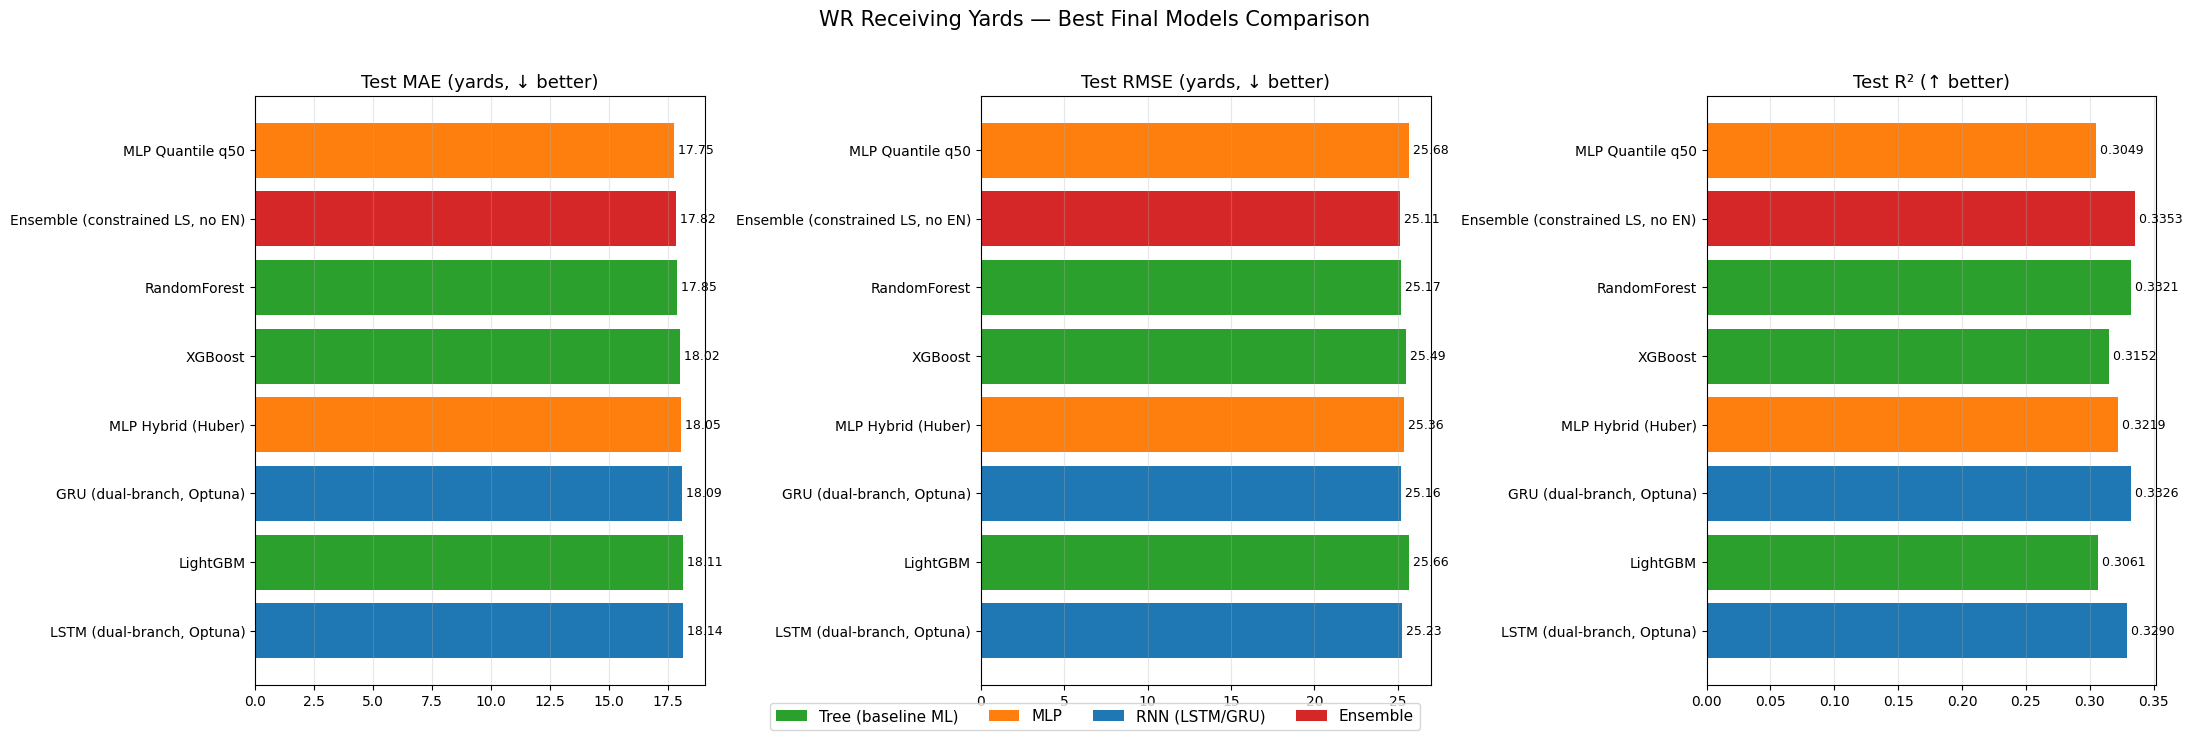

Saved: C:\Users\Korisnik\Documents\GitHub\Analiza-i-Obrada\results\wr_best_final_models_comparison.png


In [21]:
type_color = {
    'RandomForest':                '#2ca02c',
    'XGBoost':                     '#2ca02c',
    'LightGBM':                    '#2ca02c',
    'MLP Hybrid (Huber)':          '#ff7f0e',
    'MLP Quantile q50':            '#ff7f0e',
    'LSTM (dual-branch, Optuna)':  '#1f77b4',
    'GRU (dual-branch, Optuna)':   '#1f77b4',
    'Ensemble (constrained LS, no EN)': '#d62728',
}

plot_df = summary.set_index('Model')
colors = [type_color.get(m, 'gray') for m in plot_df.index]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, metric, title in zip(
    axes,
    ['Test MAE', 'Test RMSE', 'Test R2'],
    ['Test MAE (yards, ↓ better)',
     'Test RMSE (yards, ↓ better)',
     'Test R² (↑ better)'],
):
    vals = plot_df[metric].values
    bars = ax.barh(plot_df.index, vals, color=colors)
    ax.set_title(title, fontsize=13)
    ax.invert_yaxis()
    fmt = '.2f' if 'R2' not in metric else '.4f'
    for i, v in enumerate(vals):
        ax.text(v, i, f' {v:{fmt}}', va='center', fontsize=9)
    ax.grid(True, axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ca02c', label='Tree (baseline ML)'),
    Patch(facecolor='#ff7f0e', label='MLP'),
    Patch(facecolor='#1f77b4', label='RNN (LSTM/GRU)'),
    Patch(facecolor='#d62728', label='Ensemble'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('WR Receiving Yards — Best Final Models Comparison',
             fontsize=15, y=1.02)
plt.tight_layout()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(RESULTS_DIR / 'wr_best_final_models_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {RESULTS_DIR / "wr_best_final_models_comparison.png"}')

### 11.2 Predictions vs Actual (scatter, test set)


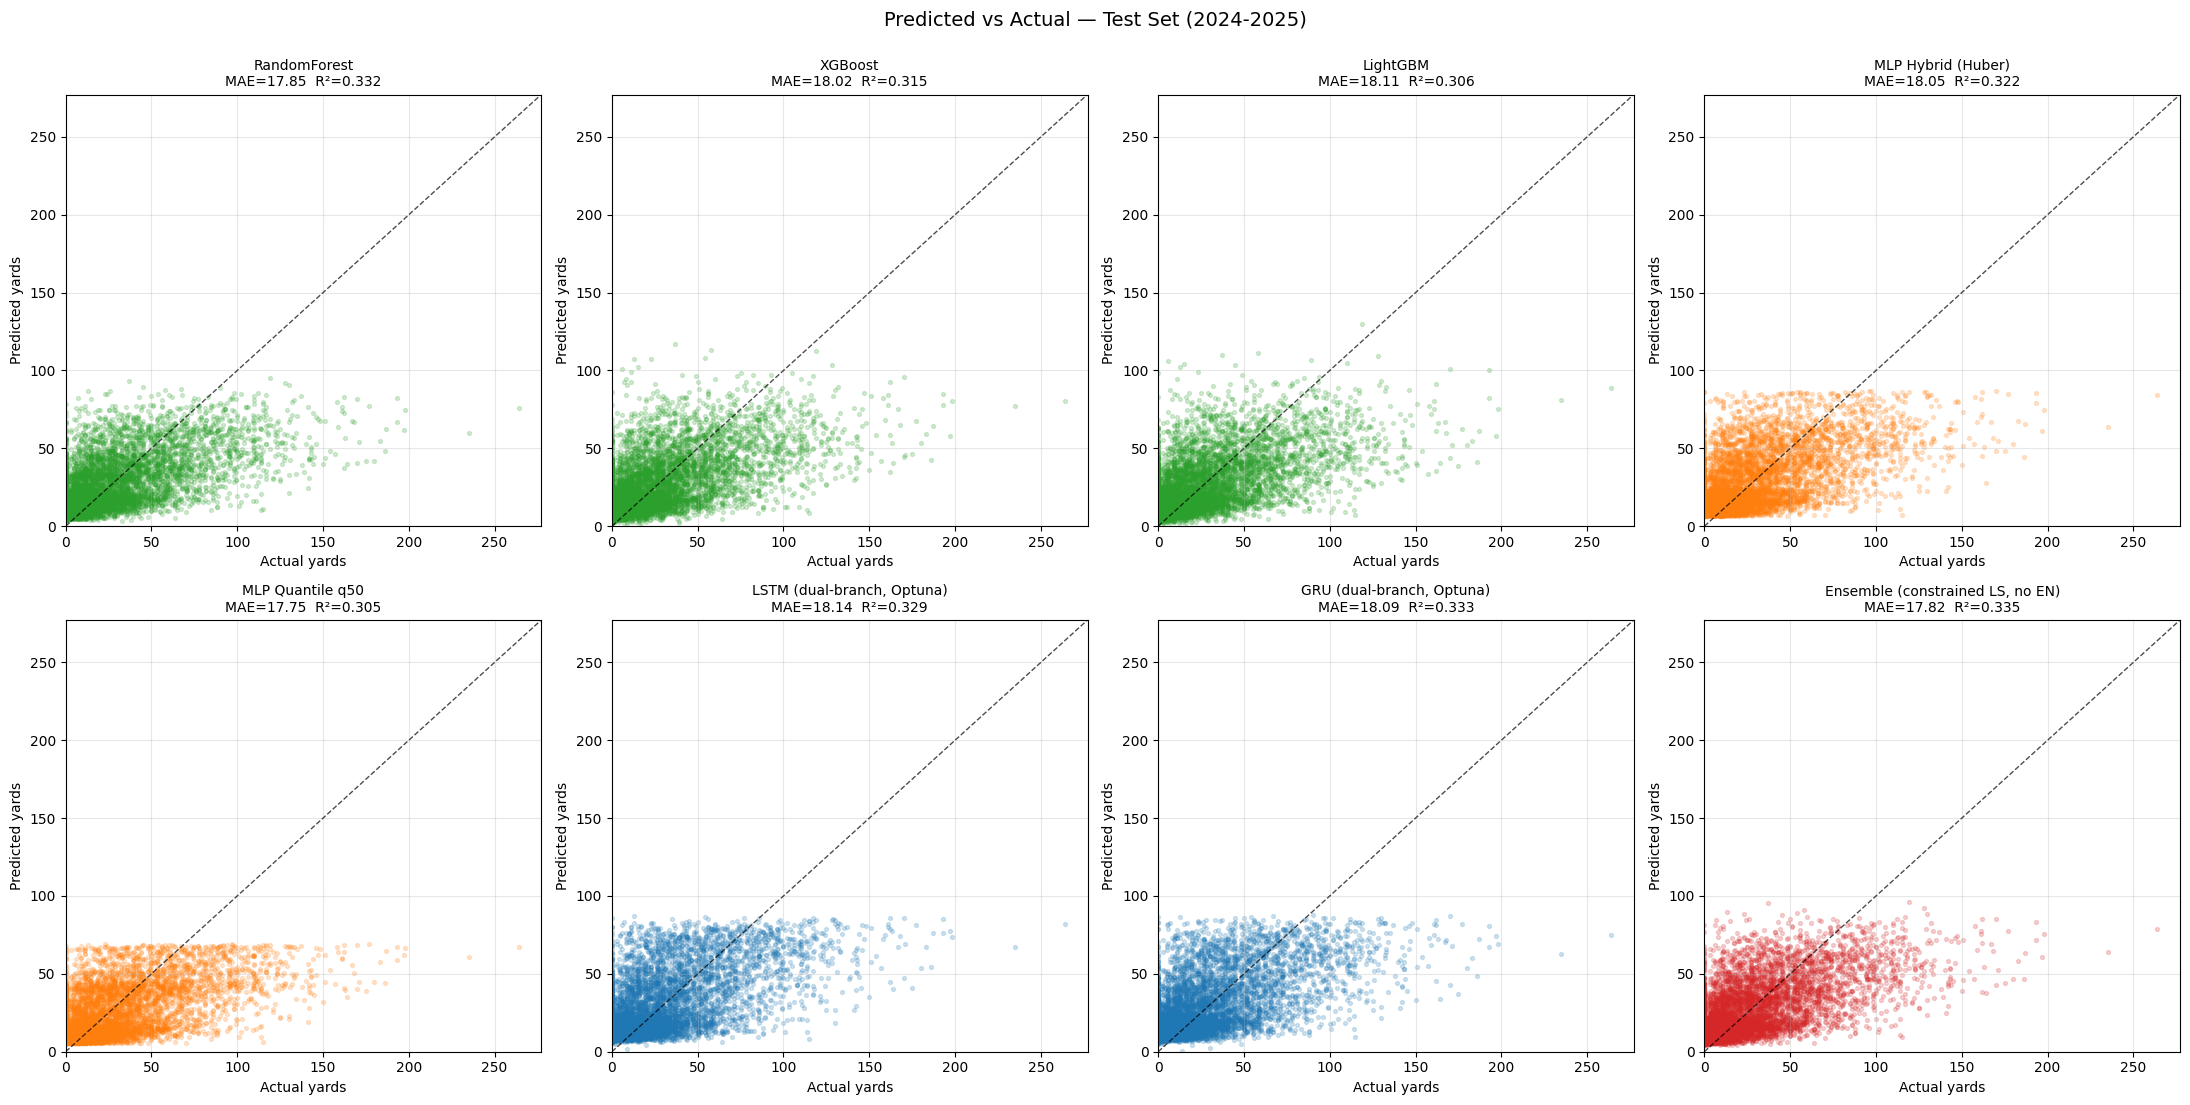

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

plot_order = [
    'RandomForest', 'XGBoost', 'LightGBM',
    'MLP Hybrid (Huber)', 'MLP Quantile q50',
    'LSTM (dual-branch, Optuna)', 'GRU (dual-branch, Optuna)',
    'Ensemble (constrained LS, no EN)',
]

for i, name in enumerate(plot_order):
    ax = axes[i]
    r = results[name]
    # use seq-space y for RNNs, otherwise tabular y_test_orig
    is_seq = 'LSTM' in name or 'GRU' in name
    y_true = y_te_orig_seq if is_seq else y_test_orig
    y_pred = r['test_pred']
    ax.scatter(y_true, y_pred, alpha=0.2, s=8, c=type_color.get(name, 'gray'))
    lim = max(y_true.max(), y_pred.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=1, alpha=0.7)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel('Actual yards'); ax.set_ylabel('Predicted yards')
    ax.set_title(f'{name}\nMAE={r["test"]["MAE"]:.2f}  R²={r["test"]["R2"]:.3f}',
                 fontsize=10)
    ax.grid(True, alpha=0.3)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.suptitle('Predicted vs Actual — Test Set (2024-2025)',
             fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'wr_best_final_pred_vs_actual.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 11.3 Residual distribution (grouped)


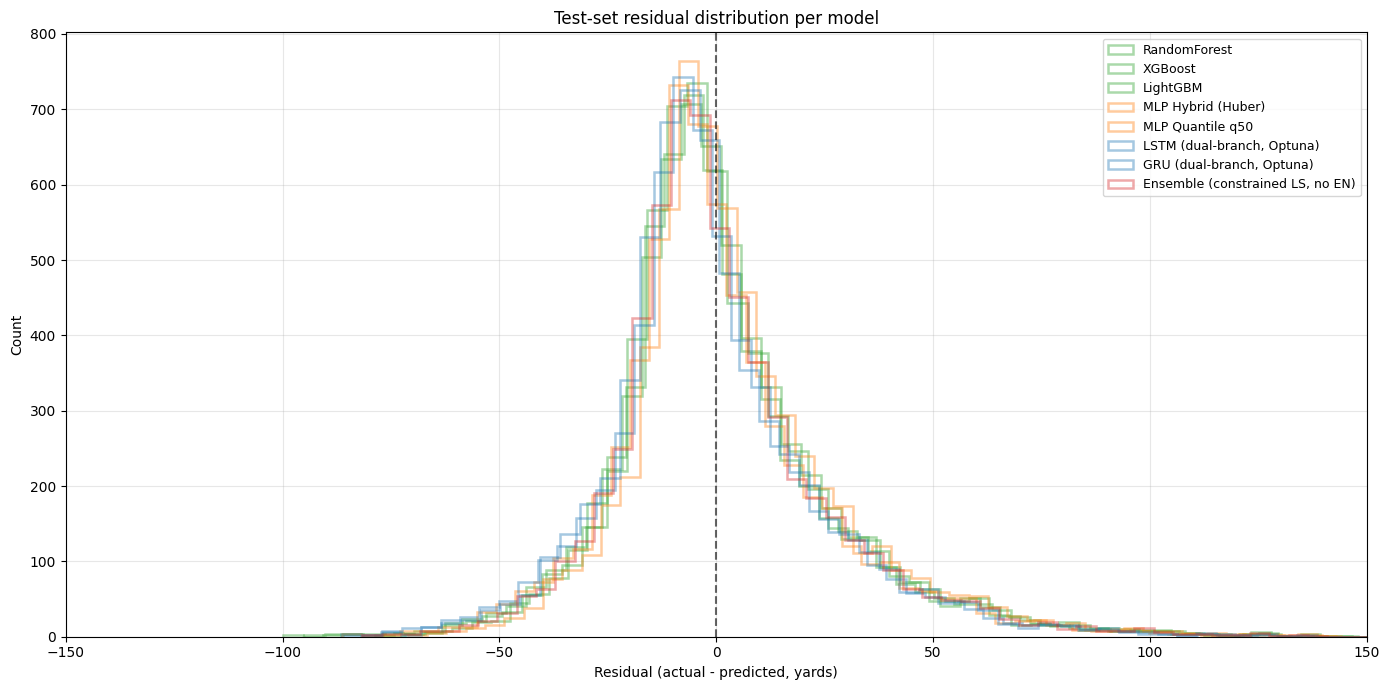

In [23]:
fig, ax = plt.subplots(figsize=(14, 7))

for name in plot_order:
    r = results[name]
    is_seq = 'LSTM' in name or 'GRU' in name
    y_true = y_te_orig_seq if is_seq else y_test_orig
    residuals = y_true - r['test_pred']
    ax.hist(residuals, bins=60, alpha=0.4, label=name,
            color=type_color.get(name, 'gray'), histtype='step', linewidth=1.8)

ax.axvline(0, color='k', linestyle='--', alpha=0.6)
ax.set_xlabel('Residual (actual - predicted, yards)')
ax.set_ylabel('Count')
ax.set_title('Test-set residual distribution per model')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(-150, 150)
plt.tight_layout()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(RESULTS_DIR / 'wr_best_final_residuals.png',
            dpi=150, bbox_inches='tight')
plt.show()

### 11.4 Final summary table — ranked


In [24]:
print('=' * 95)
print('RANKING — BY TEST MAE (lower is better)')
print('=' * 95)
ranked = summary.copy()
ranked.insert(0, 'Rank', range(1, len(ranked) + 1))
print(ranked.to_string(index=False))

print()
print('=' * 95)
print('BEST SINGLE MODEL (by Test MAE):', ranked.iloc[0]['Model'])
print('=' * 95)

# Save a final JSON with all metrics
final_output = {
    'config': {
        'seed': SEED,
        'train_seasons': train_seasons,
        'val_seasons':   val_seasons,
        'test_seasons':  test_seasons,
        'n_tabular_features': X_train.shape[1],
        'n_seq_features': n_seq_features,
        'n_static_features': n_static_features,
        'seq_len': SEQ_LEN,
    },
    'results': {
        name: {
            'val': r['val'],
            'test': r['test'],
            'seconds': r['seconds'],
        }
        for name, r in results.items()
    },
    'ensemble_weights': dict(zip(tabular_members, w_cls.tolist())),
}
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
with open(RESULTS_DIR / 'wr_best_final_models_results.json', 'w') as f:
    json.dump(final_output, f, indent=2)
print(f'Saved: {RESULTS_DIR / "wr_best_final_models_results.json"}')

RANKING — BY TEST MAE (lower is better)
 Rank                            Model  Val MAE  Val RMSE  Val R2  Test MAE  Test RMSE  Test R2  Seconds
    1                 MLP Quantile q50   17.953    26.124  0.3121    17.754     25.680   0.3049    159.4
    2 Ensemble (constrained LS, no EN)   18.069    25.491  0.3450    17.821     25.112   0.3353      0.0
    3                     RandomForest   18.129    25.543  0.3424    17.853     25.172   0.3321      9.7
    4                          XGBoost   18.187    25.769  0.3306    18.016     25.489   0.3152      1.8
    5               MLP Hybrid (Huber)   18.269    25.790  0.3296    18.046     25.365   0.3219    207.4
    6        GRU (dual-branch, Optuna)   18.254    25.424  0.3484    18.094     25.164   0.3326    143.0
    7                         LightGBM   18.203    25.961  0.3206    18.110     25.659   0.3061      4.0
    8       LSTM (dual-branch, Optuna)   18.252    25.480  0.3456    18.143     25.230   0.3290    172.0

BEST SINGLE MO